# P0 改进对比 —— 神奇公式周期处置 + 格雷厄姆盈利趋势排序

背景: 两个经典价值策略在 2023-2026 A 股窗口跑输大盘。本 notebook 验证两处根因修复:

1. **神奇公式**: 周期行业按当期 ROE 降序排名 → 在盈利顶峰买入 (周期陷阱)。修复 = 剔除周期行业 (`exclude`)。
2. **格雷厄姆**: 候选池买入顺序用&#39;安全边际&#39;(价格/有形净资产) → 买&#39;过去最便宜&#39;而非&#39;盈利仍在向上&#39;。修复 = 改为**盈利趋势排序** (TTM 净利同比、6 年净利对数斜率、ROE 水平与 3 年变化、连续增长年数)。

窗口局限: 本地个股 k 线锚定 2022-11 起 (抓取窗口), 财务报表仅 2022 后 + 有限历史, 无法前延; 本 notebook 只做**等条件隔离对比**, 不宣称长期结论。

In [1]:
import sys, os, warnings
_ROOT = os.getcwd()
for _ in range(4):
    if os.path.exists(os.path.join(_ROOT, 'strategy', 'graham_dodd.py')):
        break
    _ROOT = os.path.dirname(_ROOT)
os.chdir(_ROOT)
sys.path.insert(0, _ROOT)
warnings.filterwarnings('ignore')
import pandas as pd, numpy as np
from strategy.graham_dodd import (load_universe, load_balance, load_profit, load_market,
    load_index, perf_metrics, rebalance_dates, screen_all, GrahamStrategy,
    market_gauge, target_equity_weight, FUNNEL, margin_of_safety_score,
    profit_trend_components, rank_profit_trend,
    START, END, MIN_PASS_DEF, SIZE_QUANTILE, SELL_FLOOR,
    SECTOR_WEIGHT_CAP, SECTOR_MAX_STOCKS, GAUGE_LO_PCT, GAUGE_HI_PCT, GAUGE_LO_WEIGHT)
pd.set_option('display.width', 220); pd.set_option('display.max_columns', 40)
INITIAL_CAPITAL = 1_000_000.0
MIN_PASS = MIN_PASS_DEF
print('防御参:', f'MIN_PASS={MIN_PASS}', f'SELL_FLOOR={SELL_FLOOR}',
      f'SIZE_QUANTILE={SIZE_QUANTILE}', f'SECTOR_CAP={SECTOR_WEIGHT_CAP:.0%}/{SECTOR_MAX_STOCKS}只',
      f'GAUGE={GAUGE_LO_PCT:.0%}->{GAUGE_HI_PCT:.0%}(w={GAUGE_LO_WEIGHT:.0%})',
      f'回测区间 {pd.Timestamp(START).date()} ~ {pd.Timestamp(END).date()}')

防御参: MIN_PASS=8 SELL_FLOOR=5 SIZE_QUANTILE=0.3 SECTOR_CAP=25%/4只 GAUGE=50%->85%(w=40%) 回测区间 2023-01-01 ~ 2026-07-31


## 0. 神奇公式 · 周期行业处置

由 `strategy.magic_formula.cyclical_comparison` 刷新得到 (`reports/generated/magic_formula/nav_compare_cyclical.csv`): 三档口径同一扫描池、季度全换 Top30、含成本。主口径已定为 `exclude` (`strategy.magic_formula.DEFAULT_CYCLICAL_MODE = exclude`)。

In [2]:
from strategy.magic_formula import cyclical_comparison
_, _, modes, cmp_mf = cyclical_comparison()
rows = []
for col in cmp_mf.columns:
    s = cmp_mf[col].dropna()
    if len(s) < 2: continue
    total = s.iloc[-1] - 1
    mdd = (s / s.expanding().max() - 1).min()
    ann = s.iloc[-1] ** (1 / max((s.index[-1] - s.index[0]).days / 365.25, 1/365.25)) - 1
    rows.append({'口径': col, '期末净值': s.iloc[-1], '累计收益': total,
                 '年化': ann, '最大回撤': mdd})
mf_tab = pd.DataFrame(rows).set_index('口径')
print(mf_tab.round(4).to_string())
print('\n主口径: 剔除周期行业 (exclude)。基线(周期ROE降序)超额损失几乎全部来自周期行业在盈利顶点的排名。')

                 期末净值    累计收益      年化    最大回撤
口径                                           
基线(周期ROE降序)    0.9140 -0.0860 -0.0254 -0.3249
反向信号(周期ROE升序)  0.9926 -0.0074 -0.0021 -0.3432
排除周期行业         0.9895 -0.0105 -0.0030 -0.3381
沪深300          1.2755  0.2755  0.0722 -0.2480
中证800          1.3373  0.3373  0.0868 -0.2613

主口径: 剔除周期行业 (exclude)。基线(周期ROE降序)超额损失几乎全部来自周期行业在盈利顶点的排名。


## 1. 格雷厄姆 · 盈利趋势排序

候选池 (门禁 + 10 条件) 与全部组合规则 (估值仪表盘现金缓冲、两档卖出、行业封顶、单只 ≤15%) 完全不变, **只改买入优先序**:

- 基线 `margin_of_safety`: `margin_of_safety_score` = 价格/有形净资产 与 价格/(20×EPS) 的乘积, 值小者先买 (现在是 最便宜 优先);
- 改进 `profit_trend`: 横截面等权合成 5 个分量, 高分者先买 ——
  - `ttm_yoy`: TTM 归母净利同比 (盈利是否仍在变好的直接度量);
  - `slope`: 近 6 年年报净利对数线性斜率 (避免 c9 首尾两点被单年绑架);
  - `roe` / `roe_trend`: 最新年报 ROE 水平与 3 年变化;
  - `run`: 最近连续盈利增长年数。

数据口径: 年报净利/净资产均为公告日 ≤ 调仓日 (无前视)。

In [3]:
uni = load_universe()
has_bal = sum(1 for c in uni['code'] if load_balance(c) is not None)
has_pro = sum(1 for c in uni['code'] if load_profit(c) is not None)
has_mkt = sum(1 for c in uni['code'] if load_market(c, qfq=False) is not None)
n_cur = int((uni.kind == 'current').sum())
n_del = int((uni.kind == 'delisted').sum())
print(f'资产池: {len(uni)} 只 (当前 {n_cur} / 退市 {n_del})')
print(f'资产负债表 {has_bal} | 利润表 {has_pro} | 行情 {has_mkt}')
print('两口径共用同一次全市场扫描的候选池, 隔离买入排序这一个变量。')

资产池: 5904 只 (当前 5543 / 退市 361)
资产负债表 4283 | 利润表 4281 | 行情 4305
两口径共用同一次全市场扫描的候选池, 隔离买入排序这一个变量。


In [4]:
rbs = rebalance_dates()
screening_map = {}
for d in rbs:
    screening_map[d] = screen_all(d, min_pass=MIN_PASS)
funnel = pd.DataFrame([{'调仓日': d.date(), '终选候选': FUNNEL.get(d, {}).get('final', 0)} for d in rbs])
print(funnel.to_string(index=False))
print('候选池总量(两口径共用):', sum(len(v) for v in screening_map.values()))

       调仓日  终选候选
2023-01-03     4
2023-04-03     5
2023-07-03     8
2023-10-09     8
2024-01-02    11
2024-04-01    12
2024-07-01    21
2024-10-08    14
2025-01-02    29
2025-04-01    28
2025-07-01    33
2025-10-09    29
2026-01-05    26
2026-04-01    21
2026-07-01    24
候选池总量(两口径共用): 273


In [5]:
bt_base = GrahamStrategy(initial_capital=INITIAL_CAPITAL, rank_by='margin_of_safety')
nav_base, trades_base, _ = bt_base.run(rbs, screening_map=screening_map, end=END, verbose=False)
bt_trend = GrahamStrategy(initial_capital=INITIAL_CAPITAL, rank_by='profit_trend')
nav_trend, trades_trend, _ = bt_trend.run(rbs, screening_map=screening_map, end=END, verbose=False)

def mrow(label, nav, trades):
    m = perf_metrics(nav)
    buys = [t for t in trades if t['action'] == 'buy']
    sells = [t for t in trades if t['action'] == 'sell']
    fee = sum(t['fee'] for t in trades)
    b = pd.Series({k: m.get(k, np.nan) for k in
                   ['total_return', 'annual_return', 'annual_vol', 'sharpe', 'max_drawdown', 'win_rate']})
    b.loc['交易笔数'] = len(trades); b.loc['买入笔数'] = len(buys); b.loc['卖出笔数'] = len(sells)
    b.loc['累计费用'] = fee; b.name = label
    return b

perf = pd.DataFrame([mrow('安全边际(基线)', nav_base, trades_base),
                     mrow('盈利趋势(P0)', nav_trend, trades_trend)]).T
print('期末权益:', f'{nav_base.iloc[-1]:,.0f} / {nav_trend.iloc[-1]:,.0f} 元')
for k in ['total_return','annual_return','annual_vol','sharpe','max_drawdown','win_rate','交易笔数','买入笔数','卖出笔数','累计费用']:
    v = perf.loc[k]
    if k in ('交易笔数','买入笔数','卖出笔数','累计费用'):
        print(f'{k:<10} {v.iloc[0]:,.0f}  vs  {v.iloc[1]:,.0f}')
    else:
        print(f'{k:<10} {v.iloc[0]:+,.4f}  vs  {v.iloc[1]:+,.4f}')

期末权益: 1,064,099 / 1,124,817 元
total_return +0.0643  vs  +0.1250
annual_return +0.0176  vs  +0.0335
annual_vol +0.1617  vs  +0.1604
sharpe     -0.0148  vs  +0.0844
max_drawdown -0.2202  vs  -0.2355
win_rate   +0.4977  vs  +0.4954
交易笔数       45  vs  37
买入笔数       27  vs  23
卖出笔数       18  vs  14
累计费用       1,768  vs  1,266


In [6]:
def top_names(d, style, n=10):
    passed = [s for s, _ in screening_map.get(d, [])]
    if style == 'trend':
        rk = rank_profit_trend(passed)
        key = lambda s: (rk.get(id(s), float('inf')), s.code)
    else:
        key = lambda s: (margin_of_safety_score(s), s.code)
    return [s.name for s in sorted(passed, key=key)[:n]]

print('各调仓日 Top10 名单差异 (盈利趋势相对安全边际新进入者):')
for d in rbs:
    cand = [s for s, _ in screening_map.get(d, [])]
    base = top_names(d, 'base'); trend = top_names(d, 'trend')
    new_on_trend = [x for x in trend if x not in base]
    dropped = [x for x in base if x not in trend]
    print(f'{d.date()} 候选{len(cand)}只  差异行数 {sum(x!=y for x,y in zip(base,trend))}/{len(base)}')
    if new_on_trend or dropped:
        print(f'  进[{", ".join(new_on_trend)}]  出[{", ".join(dropped)}]')

各调仓日 Top10 名单差异 (盈利趋势相对安全边际新进入者):
2023-01-03 候选4只  差异行数 2/4
2023-04-03 候选5只  差异行数 5/5
2023-07-03 候选8只  差异行数 7/8
2023-10-09 候选8只  差异行数 8/8
2024-01-02 候选11只  差异行数 10/10
  进[中颖电子]  出[济川药业]
2024-04-01 候选12只  差异行数 7/10
  进[中颖电子, 海康威视]  出[济川药业, 仁和药业]
2024-07-01 候选21只  差异行数 10/10
  进[舍得酒业, 泸州老窖, 法拉电子, 华特达因, 金钼股份, 扬杰科技, 仙琚制药]  出[济川药业, 新开源, 华贸物流, 四川双马, 国药股份, 健康元, 仁和药业]
2024-10-08 候选14只  差异行数 10/10
  进[泸州老窖, 五 粮 液, 仙琚制药, 通化东宝]  出[四川双马, 仁和药业, 健康元, 老凤祥]
2025-01-02 候选29只  差异行数 9/10
  进[山西汾酒, 泸州老窖, 汉钟精机, 贵州茅台, 迎驾贡酒, 法拉电子, 金钼股份]  出[济川药业, 明泰铝业, 长春高新, 仁和药业, 国药股份, 健康元, 仙琚制药]
2025-04-01 候选28只  差异行数 9/10
  进[山西汾酒, 泸州老窖, 贵州茅台, 迎驾贡酒, 汉钟精机, 金钼股份, 五 粮 液]  出[济川药业, 国药股份, 仁和药业, 长春高新, 老凤祥, 健康元, 仙琚制药]
2025-07-01 候选33只  差异行数 10/10
  进[山西汾酒, 金钼股份, 贵州茅台, 泸州老窖, 迎驾贡酒, 古井贡酒, 浙江鼎力, 新开源]  出[济川药业, 国药股份, 力生制药, 长春高新, 洋河股份, 健康元, 雪峰科技, 仙琚制药]
2025-10-09 候选29只  差异行数 10/10
  进[贵州茅台, 山西汾酒, 金钼股份, 泸州老窖, 浙江鼎力, 美亚光电, 新开源, 五 粮 液, 汉钟精机]  出[济川药业, 力生制药, 国药股份, 健康元, 雪峰科技, 仙琚制药, 洋河股份, 长春高新, 山东药玻]
2026-01-05 候选26只  差异行数 10/10
  进[金钼股份, 贵州茅台, 

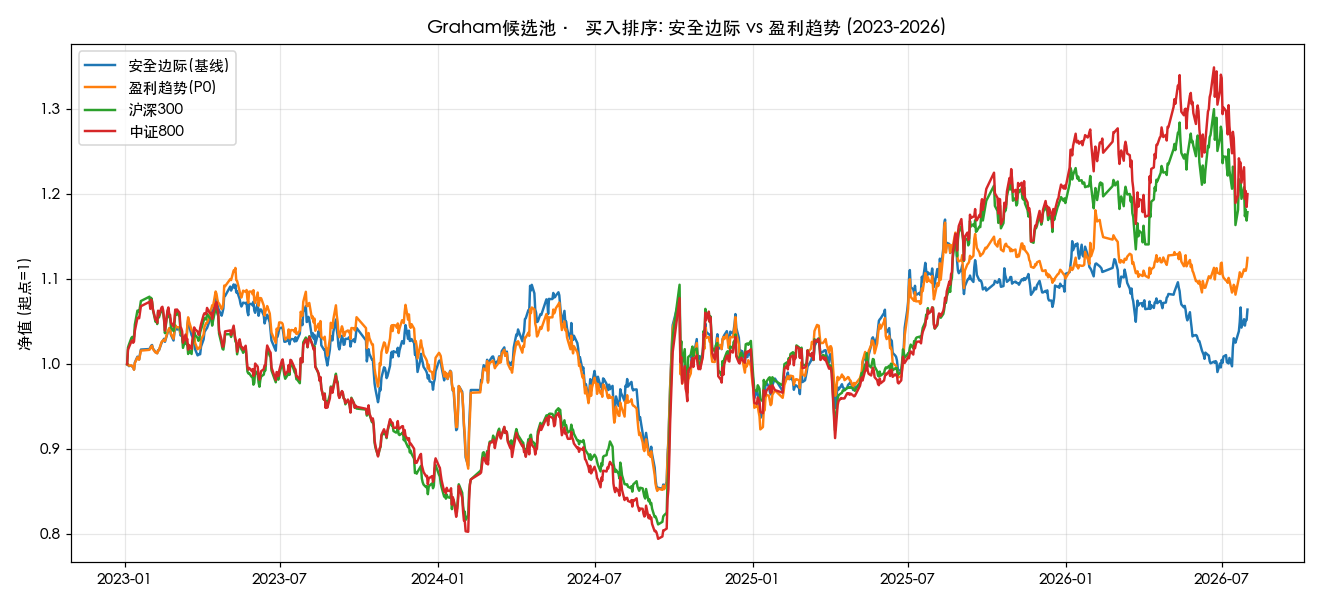

净值对比图: reports/generated/graham_dodd/nav_compare_trend.png


,安全边际(基线),盈利趋势(P0),沪深300,中证800
2026-07-24,1.0429,1.1023,1.1943,1.2132
2026-07-27,1.0528,1.1113,1.2079,1.2314
2026-07-28,1.0453,1.1102,1.1738,1.1941
2026-07-29,1.0519,1.1097,1.1817,1.2035
2026-07-30,1.0517,1.1148,1.1687,1.1846
2026-07-31,1.0641,1.1248,1.1786,1.1999


In [7]:
base = nav_base / INITIAL_CAPITAL
comp = pd.DataFrame({'安全边际(基线)': base, '盈利趋势(P0)': nav_trend / INITIAL_CAPITAL})
for label, code_ in [('沪深300', '000300'), ('中证800', '000906')]:
    x = load_index(code_).loc[comp.index[0]:comp.index[-1], 'close']
    comp[label] = x / x.iloc[0]
comp = comp.ffill().dropna(subset=['安全边际(基线)'])
comp.round(4).to_csv('reports/generated/graham_dodd/nav_compare_trend.csv')

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Heiti TC', 'STHeiti', 'Songti SC']
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('reports/generated/graham_dodd', exist_ok=True)
fig, ax = plt.subplots(figsize=(12, 5.5))
for c in comp.columns:
    ax.plot(comp[c], label=c, linewidth=1.6)
ax.set_title('Graham候选池 · 买入排序: 安全边际 vs 盈利趋势 (2023-2026)')
ax.set_ylabel('净值 (起点=1)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
img = 'reports/generated/graham_dodd/nav_compare_trend.png'
fig.savefig(img, dpi=110); plt.close(fig)
from IPython.display import Image, display
display(Image(filename=img))
print('净值对比图:', img)
comp.tail(6).round(4)

## 2. 结论与局限

- **神奇公式**: 剔除周期行业把跑输幅度从 -8.6% 收窄到 -1.0% (同期沪深300 +27.5%、中证800 +33.7%), 但组合仍为负收益 —— 周期陷阱是主要损失来源之一, 不是全部; 白酒/医药去估值与季度全换成本仍在拖累。
- **格雷厄姆盈利趋势排序**: 只改买入优先序 (其余规则不变) 后的收益/回撤边际变化以本 notebook 第 1 节数字为准; 候选池常年很小 (4~38 只), 排序空间有限, 若改善不足 2pp 属诚实结果, 说明盈利方向维度还需要更强的数据 (营收/现金流/订单)。
- **局限**: 窗口仅 2023-2026; 个股 k 线锚定 2022-11, 无法前延验证; 幸存者偏差 (当前成分/当前 ST 标签) 使回测偏乐观; 结果不构成投资建议。